# Crop Yield Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("crop_yield_train.csv")
test=pd.read_csv("crop_yield_test.csv")

In [3]:
train.shape, test.shape

((4800, 18), (1200, 17))

In [4]:
train.head()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id,yield_tpha
0,0,7.831719,37.192725,32.270297,145.627849,124.830027,11.132490,1911.116978,1.445159,0.698938,1.074339,3,Soybean,South,Autumn,2021-03-09,F0138,3.790277
1,1,6.685905,23.715684,25.852201,599.005355,120.168428,11.846171,2011.488102,0.525983,1.137722,1.718454,3,Soybean,South,Spring,2021-07-18,F0393,5.660778
2,2,8.338307,20.481400,18.202587,333.247698,270.799112,10.588497,1929.725597,2.996184,1.079680,1.386601,5,Soybean,North,Summer,2021-11-20,F0066,7.098251
3,3,7.214680,42.446504,13.758647,523.610747,99.013588,1.222238,2231.228584,2.680929,0.764238,0.814746,5,Corn,East,Summer,2021-03-02,F0150,5.461535
4,4,5.129093,16.614817,14.444958,1005.931705,169.955045,6.350100,2826.831668,1.298629,1.487599,0.910354,3,Corn,Central,Summer,2021-10-24,F0498,6.336988


In [5]:
train.isnull().sum()

id                      0
soil_ph                 0
soil_moisture           0
avg_temperature         0
total_rainfall          0
fertilizer_amount       0
pesticide_usage         0
sunlight_hours          0
nitrogen_content        0
phosphorus_content      0
potassium_content       0
irrigation_frequency    0
crop_type               0
region                  0
season                  0
harvest_date            0
field_id                0
yield_tpha              0
dtype: int64

In [6]:
test.head()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id
0,0,6.345910,45.168174,18.878330,402.879335,55.482636,9.868763,1965.143907,2.322380,1.454562,1.264197,4,Rice,South,Summer,2021-06-29,F0288
1,1,5.883224,18.481114,24.393752,1120.207408,217.295757,4.652121,2209.117515,2.498442,0.985981,1.792262,5,Soybean,East,Autumn,2021-04-28,F0083
2,2,6.773234,38.289133,11.834019,838.467434,285.188113,8.591166,2771.285499,1.227889,0.403052,1.888120,6,Rice,North,Spring,2021-05-10,F0073
3,3,8.061032,12.541429,17.721095,182.266981,175.279529,1.389547,1006.565841,2.102867,0.457953,0.640130,5,Wheat,West,Spring,2021-03-22,F0139
4,4,6.099932,26.539885,34.291265,346.149521,152.803952,6.020481,1797.104226,1.220834,0.798761,1.386482,3,Wheat,Central,Spring,2021-09-25,F0323


In [7]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

### EDA - Exploratory Data Analysis

In [8]:
df.head()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id,yield_tpha
0,0,7.831719,37.192725,32.270297,145.627849,124.830027,11.132490,1911.116978,1.445159,0.698938,1.074339,3,Soybean,South,Autumn,2021-03-09,F0138,3.790277
1,1,6.685905,23.715684,25.852201,599.005355,120.168428,11.846171,2011.488102,0.525983,1.137722,1.718454,3,Soybean,South,Spring,2021-07-18,F0393,5.660778
2,2,8.338307,20.481400,18.202587,333.247698,270.799112,10.588497,1929.725597,2.996184,1.079680,1.386601,5,Soybean,North,Summer,2021-11-20,F0066,7.098251
3,3,7.214680,42.446504,13.758647,523.610747,99.013588,1.222238,2231.228584,2.680929,0.764238,0.814746,5,Corn,East,Summer,2021-03-02,F0150,5.461535
4,4,5.129093,16.614817,14.444958,1005.931705,169.955045,6.350100,2826.831668,1.298629,1.487599,0.910354,3,Corn,Central,Summer,2021-10-24,F0498,6.336988


In [9]:
df.shape

(6000, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    6000 non-null   int64  
 1   soil_ph               6000 non-null   float64
 2   soil_moisture         6000 non-null   float64
 3   avg_temperature       6000 non-null   float64
 4   total_rainfall        6000 non-null   float64
 5   fertilizer_amount     6000 non-null   float64
 6   pesticide_usage       6000 non-null   float64
 7   sunlight_hours        6000 non-null   float64
 8   nitrogen_content      6000 non-null   float64
 9   phosphorus_content    6000 non-null   float64
 10  potassium_content     6000 non-null   float64
 11  irrigation_frequency  6000 non-null   int64  
 12  crop_type             6000 non-null   object 
 13  region                6000 non-null   object 
 14  season                6000 non-null   object 
 15  harvest_date         

In [11]:
df.describe()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,yield_tpha
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,4800.000000
mean,2039.500000,6.488416,29.799429,22.534390,663.307044,173.084247,7.481567,1999.183462,1.745484,0.848041,1.254230,3.503000,6.266544
std,1441.785828,1.158148,11.479918,7.215781,317.930401,71.269593,4.335514,579.096735,0.726311,0.373470,0.432073,1.701119,1.152830
min,0.000000,4.500047,10.002113,10.006311,100.052936,50.027558,0.000083,1000.360078,0.500042,0.200136,0.500013,1.000000,2.336034
25%,749.750000,5.482910,19.955738,16.291892,392.567516,111.786366,3.677076,1502.182174,1.104876,0.525189,0.888870,2.000000,5.456201
50%,1799.500000,6.493177,29.638880,22.598685,665.825853,173.340947,7.517519,1995.882092,1.739653,0.852895,1.254376,4.000000,6.300939
75%,3299.250000,7.489804,39.735612,28.830480,937.080196,232.930386,11.194419,2508.632528,2.381842,1.164345,1.633936,5.000000,7.080690
max,4799.000000,8.498871,49.986928,34.998121,1199.891075,299.933021,14.996841,2999.781129,2.999930,1.499794,1.999910,6.000000,9.539713


In [12]:
df.isnull().sum()

id                         0
soil_ph                    0
soil_moisture              0
avg_temperature            0
total_rainfall             0
fertilizer_amount          0
pesticide_usage            0
sunlight_hours             0
nitrogen_content           0
phosphorus_content         0
potassium_content          0
irrigation_frequency       0
crop_type                  0
region                     0
season                     0
harvest_date               0
field_id                   0
yield_tpha              1200
dtype: int64

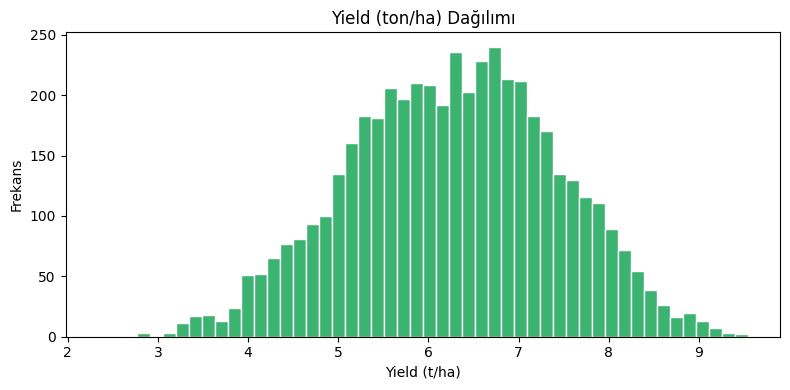

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df['yield_tpha'].dropna(), bins=50, color='mediumseagreen', edgecolor='white')
plt.title('Yield (ton/ha) Dağılımı')
plt.xlabel('Yield (t/ha)')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

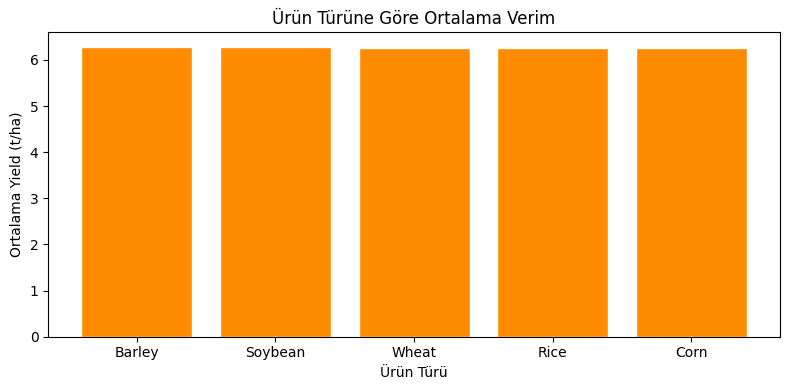

In [14]:
crop_yield = df.groupby('crop_type')['yield_tpha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(crop_yield.index, crop_yield.values, color='darkorange', edgecolor='white')
plt.title('Ürün Türüne Göre Ortalama Verim')
plt.xlabel('Ürün Türü')
plt.ylabel('Ortalama Yield (t/ha)')
plt.tight_layout()
plt.show()

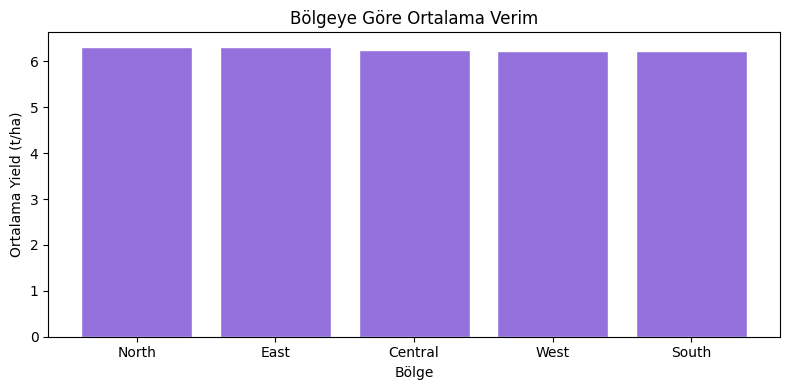

In [15]:
region_yield = df.groupby('region')['yield_tpha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(region_yield.index, region_yield.values, color='mediumpurple', edgecolor='white')
plt.title('Bölgeye Göre Ortalama Verim')
plt.xlabel('Bölge')
plt.ylabel('Ortalama Yield (t/ha)')
plt.tight_layout()
plt.show()

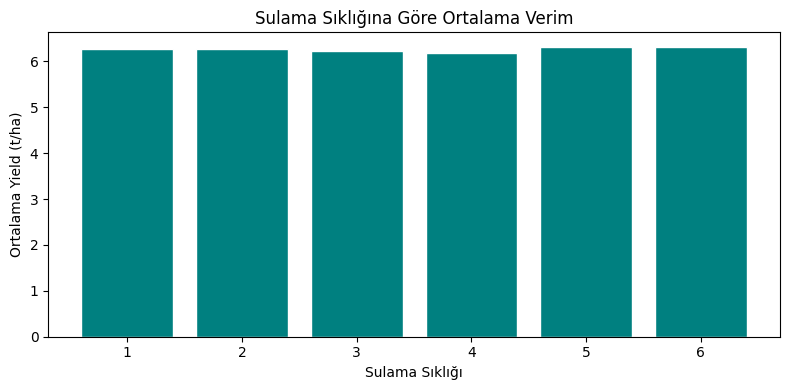

In [16]:
irr_yield = df.groupby('irrigation_frequency')['yield_tpha'].mean()

plt.figure(figsize=(8, 4))
plt.bar(irr_yield.index.astype(str), irr_yield.values, color='teal', edgecolor='white')
plt.title('Sulama Sıklığına Göre Ortalama Verim')
plt.xlabel('Sulama Sıklığı')
plt.ylabel('Ortalama Yield (t/ha)')
plt.tight_layout()
plt.show()

<Axes: >

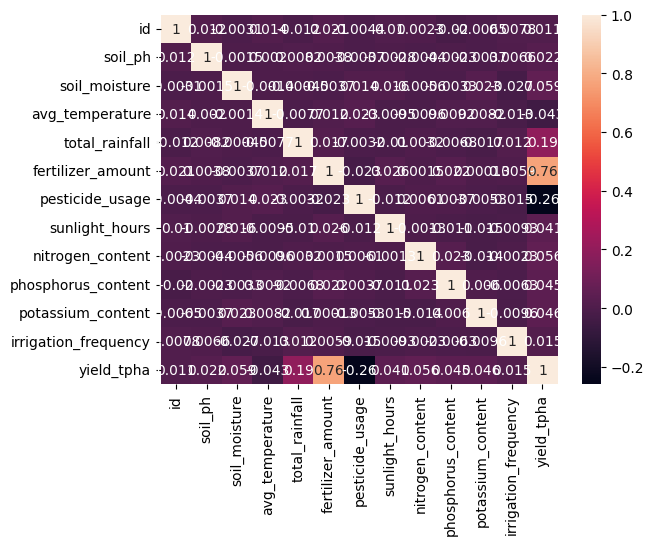

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Feature Engineering

In [18]:
df.head()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id,yield_tpha
0,0,7.831719,37.192725,32.270297,145.627849,124.830027,11.132490,1911.116978,1.445159,0.698938,1.074339,3,Soybean,South,Autumn,2021-03-09,F0138,3.790277
1,1,6.685905,23.715684,25.852201,599.005355,120.168428,11.846171,2011.488102,0.525983,1.137722,1.718454,3,Soybean,South,Spring,2021-07-18,F0393,5.660778
2,2,8.338307,20.481400,18.202587,333.247698,270.799112,10.588497,1929.725597,2.996184,1.079680,1.386601,5,Soybean,North,Summer,2021-11-20,F0066,7.098251
3,3,7.214680,42.446504,13.758647,523.610747,99.013588,1.222238,2231.228584,2.680929,0.764238,0.814746,5,Corn,East,Summer,2021-03-02,F0150,5.461535
4,4,5.129093,16.614817,14.444958,1005.931705,169.955045,6.350100,2826.831668,1.298629,1.487599,0.910354,3,Corn,Central,Summer,2021-10-24,F0498,6.336988


In [19]:
df['harvest_date'] = pd.to_datetime(df['harvest_date'])
df['harvest_month'] = df['harvest_date'].dt.month

In [20]:
df['npk_total'] = df['nitrogen_content'] + df['phosphorus_content'] + df['potassium_content']

In [21]:
df['fertilizer_per_rainfall'] = df['fertilizer_amount'] / (df['total_rainfall'] + 1)

In [22]:
df['fertilizer_per_irrigation'] = df['fertilizer_amount'] / (df['irrigation_frequency'] + 1)

In [23]:
df['ph_deviation'] = abs(df['soil_ph'] - 6.75)

In [24]:
df['humidity_index'] = df['total_rainfall'] / (df['avg_temperature'] + 1)

In [25]:
df.select_dtypes(include='object').head(5)

,crop_type,region,season,field_id
0,Soybean,South,Autumn,F0138
1,Soybean,South,Spring,F0393
2,Soybean,North,Summer,F0066
3,Corn,East,Summer,F0150
4,Corn,Central,Summer,F0498


In [26]:
df['season'] = df['season'].map({'Spring':1,'Summer':2,'Autumn':3,'Winter':4})

## Train Test Split

In [27]:
train = df[df['yield_tpha'].notna()]
test  = df[df['yield_tpha'].isna()]

In [28]:
columns = ['fertilizer_amount','pesticide_usage','total_rainfall', 'soil_moisture','nitrogen_content','ph_deviation',
    'npk_total','avg_temperature','sunlight_hours','irrigation_frequency','crop_type','region']

In [29]:
x = train[columns]
y = train['yield_tpha']

In [30]:
x_final_test = test[columns]

In [31]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [32]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

In [33]:
def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [34]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.686523,0.649606,0.519087
Ridge,0.683340,0.652896,0.520444
Linear,0.683328,0.652908,0.520454
ElasticNet,0.646554,0.689778,0.552977
XGBRegressor,0.630777,0.705004,0.562801
Lasso,0.605310,0.728913,0.587602
KNeighborsRegressor,0.485110,0.832539,0.670624
Decision Tree,0.416211,0.886494,0.704643
Extra Tree,0.271173,0.990512,0.792204


In [36]:
model =Ridge()
scaling_needed = model in ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'KNeighbors']

if scaling_needed:
    print("StandardScaler uygulanıyor...")
    scaler = StandardScaler()
    x_scaled            = scaler.fit_transform(x)
    x_final_test_scaled = scaler.transform(x_final_test)
    model.fit(x_scaled, y)
    predictions = model.predict(x_final_test_scaled)
else:
    model.fit(x, y)
    predictions = model.predict(x_final_test)

print(f"Tahmin tamamlandı → {len(predictions)} satır")

Tahmin tamamlandı → 1200 satır


In [37]:
submission = pd.DataFrame({
    'id'        : test['id'].values,
    'yield_tpha': predictions
})

In [38]:
submission.head()

,id,yield_tpha
0,0,4.752814
1,1,7.415539
2,2,7.983783
3,3,6.097964
4,4,5.728800


In [39]:
submission.to_csv('submission.csv', index=False)